In [122]:
import pandas as pd

In [123]:
import optuna

STORAGE = "sqlite:///optuna.db"

# список всех исследований (study_name)
print("Studies in storage:")
for s in optuna.study.get_all_study_summaries(storage=STORAGE):
    print(f"- {s.study_name}, direction={s.direction}, trials={s.n_trials}")


Studies in storage:
- optuna/age, direction=1, trials=101
- optuna/alphabattle_small, direction=1, trials=100
- optuna/v2/age, direction=1, trials=10
- optuna/v3/age, direction=1, trials=1
- optuna/v4/age, direction=1, trials=1
- optuna/v5/age, direction=1, trials=1
- optuna/v6/age, direction=1, trials=1
- optuna/v20/age, direction=1, trials=16
- optuna/test/age, direction=1, trials=11
- optuna/v200/age, direction=1, trials=100
- optuna/test1/age, direction=1, trials=1
- optuna/test2/age, direction=1, trials=2
- optuna/test3/age, direction=1, trials=2
- optuna/test4/age, direction=1, trials=4
- optuna/test5/age, direction=1, trials=4
- optuna/test6/age, direction=1, trials=8
- optuna/v2/alphabattle_small, direction=1, trials=5
- optuna/v3/alphabattle_small, direction=1, trials=1
- optuna/v4/alphabattle_small, direction=1, trials=1
- optuna/v5/alphabattle_small, direction=1, trials=300
- optuna/v1/alphabattle_full, direction=1, trials=307
- optuna/test_0/age, direction=1, trials=1
- opt

In [147]:
# --- базовая загрузка ---
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

STUDY   = "shakespeare/final_01"              # имя вашего исследования
METRIC  = "loss"                 # столбец-метрика (Optuna кладёт целевую сюда)

study  = optuna.load_study(storage=STORAGE, study_name=STUDY)
trials = study.get_trials(deepcopy=False)

def trials_to_df(trials) -> pd.DataFrame:
    rows = []
    for t in trials:
        row = {
            "trial": t.number,
            "state": str(t.state),
            "value": t.value,
            "start": t.datetime_start,
            "end":   t.datetime_complete,
        }
        row["duration_sec"] = (
            (t.datetime_complete - t.datetime_start).total_seconds()
            if t.datetime_start and t.datetime_complete else np.nan
        )
        # расплющиваем параметры
        for k, v in t.params.items():
            row[f"param::{k}"] = v
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("trial").reset_index(drop=True)
    return df

df = trials_to_df(trials)
df_completed = df[df["state"] == "TrialState.COMPLETE"].copy()

print("Всего трейлов:", len(df), " | завершено:", len(df_completed))
display(df_completed.sort_values('value', ascending=False))


Всего трейлов: 200  | завершено: 32


,trial,state,value,start,end,duration_sec,param::optim.lr,param::optim.weight_decay,param::lr_scheduler.num_warmup_steps,param::training.ema,param::model.hidden_size,param::model.n_heads,param::model.n_blocks,param::model.cond_dim,param::model.dropout,param::noise.sigma_min,param::noise.sigma_max,param::training.sampling_eps,param::time_conditioning
10,10,TrialState.COMPLETE,2.39936,2025-09-15 18:42:44.761281,2025-09-15 18:55:07.606915,742.845634,0.000016,1.635211e-11,200,0.9970,768,24,4,32,0.104460,0.000395,9.948638,0.000235,True
8,8,TrialState.COMPLETE,1.82717,2025-09-15 18:35:08.109061,2025-09-15 18:42:19.357154,431.248093,0.000347,2.006655e-08,100,0.9999,128,8,8,128,0.243558,0.004216,33.721133,0.003444,True
5,5,TrialState.COMPLETE,1.80225,2025-09-15 17:50:06.996515,2025-09-15 18:10:21.559471,1214.562956,0.000061,7.694166e-03,1000,0.9970,768,8,8,64,0.185034,0.007032,69.678061,0.003180,False
13,13,TrialState.COMPLETE,1.76839,2025-09-15 19:06:32.467720,2025-09-15 19:14:41.110891,488.643171,0.000297,1.345007e-10,200,0.9999,128,4,12,64,0.119930,0.001220,5.059494,0.000653,False
4,4,TrialState.COMPLETE,1.70870,2025-09-15 17:26:08.702044,2025-09-15 17:50:06.974645,1438.272601,0.000998,7.561474e-09,100,0.9990,512,8,16,256,0.047037,0.000011,6.071347,0.002054,False
2,2,TrialState.COMPLETE,1.60578,2025-09-15 16:51:50.438513,2025-09-15 17:12:20.458706,1230.020193,0.002187,7.337539e-07,100,0.9999,768,24,8,64,0.271014,0.000526,5.039950,0.004631,True
3,3,TrialState.COMPLETE,1.56329,2025-09-15 17:12:20.480988,2025-09-15 17:26:08.680430,828.199442,0.001565,3.738502e-09,1000,0.9990,256,8,16,64,0.175728,0.008106,23.687417,0.000112,False
89,89,TrialState.COMPLETE,1.55688,2025-09-16 01:31:23.728927,2025-09-16 01:55:08.753212,1425.024285,0.001960,6.180817e-11,200,0.9970,768,8,10,32,0.059524,0.007371,5.503358,0.033508,False
35,35,TrialState.COMPLETE,1.55601,2025-09-15 20:32:17.955337,2025-09-15 20:49:04.582863,1006.627526,0.001242,2.436715e-07,200,0.9990,512,16,10,64,0.185740,0.000261,5.653086,0.000126,False
11,11,TrialState.COMPLETE,1.55094,2025-09-15 18:55:07.636025,2025-09-15 19:06:16.405368,668.769343,0.000498,4.869000e-06,200,0.9999,256,16,10,32,0.008301,0.001689,7.758635,0.000703,False


In [148]:
from plotly.io import show

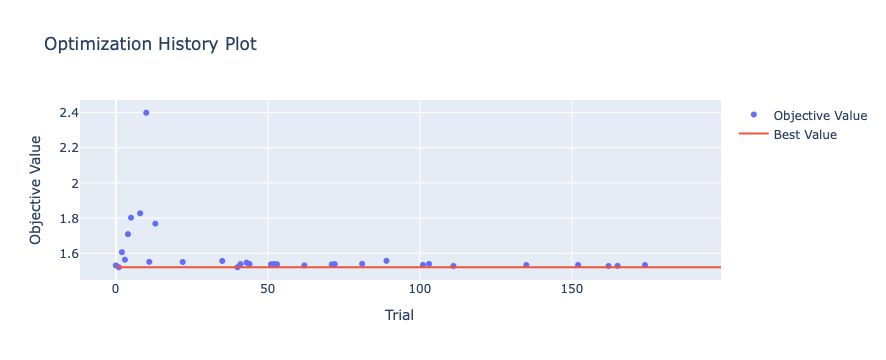

In [149]:
fig = optuna.visualization.plot_optimization_history(study)
show(fig)

In [136]:
import optuna

study = optuna.load_study(storage=STORAGE, study_name=STUDY)
print("Best value:", study.best_value)
print("Best params:", study.best_params)
print("Trials:", len(study.trials))


Best value: 2.26603
Best params: {'optim.lr': 0.00248068415370755, 'optim.weight_decay': 1.3012582180654255e-11, 'lr_scheduler.num_warmup_steps': 500, 'training.ema': 0.997, 'model.hidden_size': 768, 'model.n_heads': 24, 'model.n_blocks': 10, 'model.cond_dim': 32, 'model.dropout': 0.0038618770646085265, 'noise.sigma_min': 0.00046404440743915885, 'noise.sigma_max': 59.212867449879376, 'training.sampling_eps': 0.005703147305585778, 'time_conditioning': True}
Trials: 103


In [137]:
from optuna.importance import get_param_importances

imps = get_param_importances(study)
for k, v in imps.items():
    print(f"{k:30s} {v:.4f}")


model.n_blocks                 0.2283
training.sampling_eps          0.2064
model.n_heads                  0.1247
optim.lr                       0.1186
lr_scheduler.num_warmup_steps  0.0690
model.dropout                  0.0647
model.hidden_size              0.0546
training.ema                   0.0494
noise.sigma_max                0.0388
model.cond_dim                 0.0290
noise.sigma_min                0.0129
time_conditioning              0.0035
optim.weight_decay             0.0000


In [41]:
gt = pd.read_parquet('../outputs/age/2025.09.08/170939/evaluation/gt.parquet')
gen = pd.read_parquet('../outputs/age/2025.09.08/170939/evaluation/gen.parquet')

In [42]:
gt.iloc[20].small_group[-32:]

array([ 1,  3,  1,  1,  1, 16,  1,  7, 16,  5,  1,  1,  3,  7,  1,  5,  1,
        7,  1,  1,  1,  7,  1, 29,  1,  1,  1,  1,  7,  1,  1,  3])

In [43]:
gen.iloc[20].small_group[-32:]

array([ 1,  3,  4,  2,  1, 12,  1,  1,  7,  1,  7,  1,  1,  1,  1,  1,  5,
        1,  1,  3,  7,  1,  1,  1,  1,  7,  2, 10, 31, 37,  1,  3])